### Import libraries

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression

### Read real/fake news dataset

In [14]:
data = pd.read_csv("./dataset/data.csv")
display(data.head(10))
print(data.shape)
print(data.isna().sum())

,label,title,text,subject,date
0,1,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,1,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,1,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,1,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"
5,1,"White House, Congress prepare for talks on spe...","WEST PALM BEACH, Fla./WASHINGTON (Reuters) - T...",politicsNews,"December 29, 2017"
6,1,"Trump says Russia probe will be fair, but time...","WEST PALM BEACH, Fla (Reuters) - President Don...",politicsNews,"December 29, 2017"
7,1,Factbox: Trump on Twitter (Dec 29) - Approval ...,The following statements were posted to the ve...,politicsNews,"December 29, 2017"
8,1,Trump on Twitter (Dec 28) - Global Warming,The following statements were posted to the ve...,politicsNews,"December 29, 2017"
9,1,Alabama official to certify Senator-elect Jone...,WASHINGTON (Reuters) - Alabama Secretary of St...,politicsNews,"December 28, 2017"


(39942, 5)
label      0
title      0
text       0
subject    0
date       0
dtype: int64


### Drop duplicate news by title

In [15]:
data.drop_duplicates(subset=['title'], inplace=True)
print(data.shape)

(36083, 5)


### Split dataset into train and test datasets 80%/20%

In [16]:
from sklearn.model_selection import train_test_split

data_train, data_val = train_test_split(data, test_size=0.2, random_state=42)

In [17]:
print(f"data_train: {data_train.shape}")
print(f"data_val: {data_val.shape}")

data_train: (28866, 5)
data_val: (7217, 5)


### Execute data preprocessing adding three columns ['content', 'tokens', 'preprocessed_text']
- **content**: news title + news text
- **tokens**: content tokenized
- **preprocessed_text**: text cleaned from stopwords, punctuations, spaces and lemmatized

In [18]:
from preprocessing import get_preprocessing_attributes

data_train_preprocessed = get_preprocessing_attributes(data_train)
data_val_preprocessed = get_preprocessing_attributes(data_val)

### Bag of words + Logistic regression algortihm

In [19]:
# BoW + Logistic regression
count_vectorizer = CountVectorizer()
X_train_count = count_vectorizer.fit_transform(data_train_preprocessed['preprocessed_text'])
X_val_count = count_vectorizer.transform(data_val_preprocessed['preprocessed_text'])

lr_bow_classifier = LogisticRegression()
lr_bow_classifier.fit(X_train_count, data_train_preprocessed['label'])

lr_bow_pred = lr_bow_classifier.predict(X_val_count)

### Classification report + confussion matrix for output analysis

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3313
           1       0.99      1.00      0.99      3904

    accuracy                           0.99      7217
   macro avg       0.99      0.99      0.99      7217
weighted avg       0.99      0.99      0.99      7217



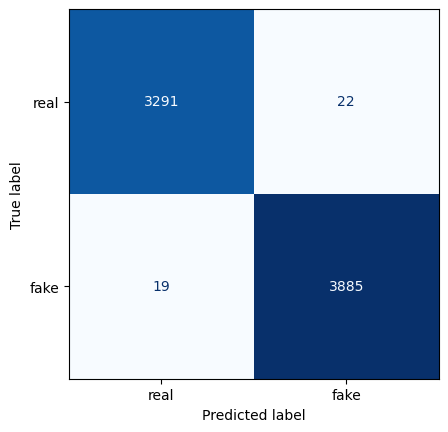

In [20]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

print(classification_report(data_val_preprocessed['label'], lr_bow_pred))

ConfusionMatrixDisplay.from_predictions(
    data_val_preprocessed['label'],
    lr_bow_pred,
    display_labels=['real', 'fake'],
    cmap='Blues',
    colorbar=False
)

plt.show()

### Export model as pickel (*.pkl)

In [21]:
import joblib
from sklearn.pipeline import Pipeline

nlp_model = Pipeline([
    ('vectorizer', count_vectorizer),
    ('classifier', lr_bow_classifier)
])
joblib.dump(nlp_model, 'nlp_model.pkl')

['nlp_model.pkl']